# Explainable Motor Claims Triage with CATE

**Goal.** When a motor (auto) claim arrives, an insurer can route it to a *specialist fast-track handler* or leave it in *standard processing*. Handling complex claims well reduces **claims leakage** (the money paid above what a claim should cost), but a specialist is a scarce, expensive resource. We therefore do not want to know only *whether* specialists help on average — we want to know **for which claims** they help most, so we can triage the incoming queue.

This is a **conditional average treatment effect (CATE)** problem,

$$\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x],$$

where the treatment $T$ is *specialist handling*, the outcome $Y$ is the *final claim cost*, and $X$ are claim/policy features. We estimate $\tau(x)$ with two complementary tools from the tutorial and then make the estimate **explainable** with Shapley values:

| Step | Method | Tutorial reference |
|------|--------|--------------------|
| Average effect (debiased) | **Double Machine Learning** | {doc}`../tutorial/regression_methods` ({prf:ref}`alg-dml`) |
| Individual effect $\hat{\tau}(x)$ | **Causal Forest** | {doc}`../tutorial/Tree_Based_Methods` ({prf:ref}`alg-causalforest`) |
| *Why* a claim has its effect | **SHAP values + waterfall plot** | explainability layer |

Because we need a *known* ground-truth effect to grade the estimators against — and because public motor-claims datasets contain no treatment/counterfactual — we simulate a realistic motor-claims portfolio with deliberate confounding.


````{admonition} Setup: running this notebook on a Mac
:class: tip, dropdown
This tutorial runs locally with a self-contained Python environment. The steps below assume a **MacBook** with a terminal (and [VS Code](https://code.visualstudio.com/) or JupyterLab to open the notebook).

**1. Check you have Python 3.10+.** macOS ships an older Python, so install a current one if needed:

```bash
python3 --version          # need 3.10 or newer
brew install python@3.11   # if not, install via Homebrew (https://brew.sh)
```

**2. Create and activate a virtual environment** in the project folder (keeps these packages isolated):

```bash
cd path/to/causalinference
python3 -m venv .venv
source .venv/bin/activate   # prompt now shows (.venv)
```

**3. Install the packages this notebook needs:**

```bash
pip install --upgrade pip
pip install numpy pandas matplotlib seaborn scikit-learn networkx econml shap lightgbm
# or, if a requirements file is provided:
# pip install -r application/requirements.txt
```

**4. Register the environment as a Jupyter kernel** so you can pick it from the notebook:

```bash
pip install ipykernel jupyterlab
python -m ipykernel install --user --name claims-triage --display-name "Python (claims-triage)"
```

**5. Open the notebook and select the kernel.**
- *In VS Code:* open `claims_triage.ipynb`, click the **kernel picker** in the top-right, and choose **Python (claims-triage)** (or "Select Another Kernel → Python Environments → .venv").
- *In JupyterLab:* run `jupyter lab`, open the notebook, then **Kernel → Change Kernel → Python (claims-triage)**.

**6. Run it.** Execute the cells top to bottom (`Shift+Enter`, or *Run All*). The first import cell pulls in `econml` and `shap`; if it errors with *ModuleNotFoundError*, double-check that the selected kernel is the `.venv` you installed into.

> **Tip:** `econml` may print harmless numerical-overflow warnings during inference — they are silenced with `np.errstate(...)` where relevant and do not affect the results.
````


## Actuarial Relevance
```{admonition} Why this matters to an actuary
:class: important
Claims triage sits squarely on the actuarial control cycle — it touches the **loss ratio**, expense loadings, reserves and pricing, and it must be **governed and explainable**:

- **Claims leakage is a loss-ratio lever.** Every CHF of leakage avoided flows straight to the combined ratio. Quantifying the *causal* saving from specialist handling — not the confounded raw difference — gives a defensible estimate of the loss-cost reduction the intervention actually buys.
- **It is an expense/ROI decision under a budget.** A specialist is a costly, scarce resource. The capacity-constrained policy in Section 6 is exactly the actuarial trade-off between an expense loading (handling cost) and the expected reduction in incurred losses — i.e. *where does the next CHF of claims-handling spend earn its best return?*
- **Reserving and BE assumptions.** If a triage rule is rolled out, the expected ultimate cost of routed claims changes. Knowing $\hat{\tau}(x)$ feeds directly into best-estimate assumptions and case-reserve adjustments, and avoids double-counting a saving that was really just confounding.
- **Pricing and risk selection.** The same CATE machinery underlies "which policyholder benefits most from intervention X" questions — telematics nudges, fraud screening, retention offers — letting the actuary target actions rather than apply them uniformly.
- **Governance, fairness and auditability.** Actuarial and regulatory standards (and the {doc}`../tutorial/fairness` material) demand that automated decisions be explainable and free of unfair discrimination. The SHAP layer turns each routing decision into an auditable rationale, and the sensitivity analysis in Section 7 states honestly how much unobserved confounding the conclusion can tolerate — the kind of robustness statement an actuary needs before signing off a model.

In short: this is a causal, cost-aware, and explainable version of a classic actuarial question — *spend a limited handling budget where it reduces ultimate claims cost the most* — built so it can survive peer review and a fairness/conduct audit.
```



## The causal setup

- **Treatment** $T$ — the claim is assigned a *specialist fast-track handler* ($T=1$) instead of standard processing ($T=0$).
- **Outcome** $Y$ — the *final claim cost* in CHF. **Lower is better**, so a *negative* treatment effect is a *saving*.
- **Confounding** — in the historical data, specialists were not assigned at random. Adjusters already sent the *severe, injury-related* claims to specialists. Those claims are intrinsically expensive, so a naive "specialist vs. standard" cost comparison makes specialists look *harmful*. This is the classic {doc}`confounding` trap that {prf:ref}`alg-dml` and {prf:ref}`alg-causalforest` are built to break.

```{admonition} Identification
:class: note
We assume **unconfoundedness** given the recorded claim features $X$ (the adjuster routed on information we observe) and **overlap** (every type of claim had some chance of either route). Under these assumptions the estimators below recover $\tau(x)$ despite the biased assignment.
```


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingRegressor,
)
from econml.dml import LinearDML, CausalForestDML
import shap

from utils import *

rng = np.random.default_rng(42)
apply_sav_theme()
plt.rcParams["figure.figsize"] = (8, 5)


### The causal graph

The DAG below makes the confounding explicit. The claim features $X$ are **common causes**: they drive the routing decision $T$ (adjusters send severe claims to specialists) *and* the final cost $Y$. The path $T \rightarrow Y$ is the causal effect $\tau(x)$ we want; the back-door path $T \leftarrow X \rightarrow Y$ is the bias the naive comparison picks up. Conditioning on $X$ (as DML and the causal forest do) blocks that back-door path.


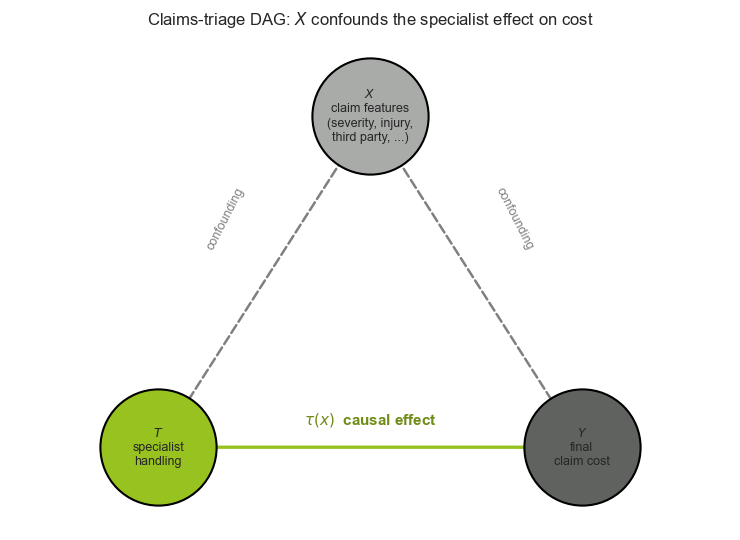

In [42]:
import networkx as nx
from matplotlib.patches import FancyArrowPatch

G = nx.DiGraph()
G.add_edges_from([("X", "T"), ("X", "Y"), ("T", "Y")])

pos = {"X": (0.5, 1.0), "T": (0.0, 0.0), "Y": (1.0, 0.0)}
node_colors = {"X": SAV_GREY_LIGHT, "T": SAV_GREEN, "Y": SAV_CHARCOAL}
node_labels = {
    "X": "$X$\nclaim features\n(severity, injury,\nthird party, ...)",
    "T": "$T$\nspecialist\nhandling",
    "Y": "$Y$\nfinal\nclaim cost",
}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Edges: solid = causal effect of interest, dashed grey = confounding back-door
edge_style = {("T", "Y"): (SAV_GREEN, "-", 2.4),
              ("X", "T"): (SAV_GREY, "--", 1.8),
              ("X", "Y"): (SAV_GREY, "--", 1.8)}
for (u, v), (color, ls, lw) in edge_style.items():
    arrow = FancyArrowPatch(pos[u], pos[v], arrowstyle="-|>", mutation_scale=22,
                            color=color, lw=lw, ls=ls,
                            shrinkA=26, shrinkB=26, zorder=1)
    ax.add_patch(arrow)

for node, (x, y) in pos.items():
    ax.scatter(x, y, s=7000, c=node_colors[node], edgecolors="black",
               linewidths=1.5, zorder=2)
    ax.text(x, y, node_labels[node], ha="center", va="center", fontsize=9, zorder=3)

# Annotate the edges
ax.text(0.5, 0.07, r"$\tau(x)$  causal effect", color=SAV_GREEN_DARK,
        ha="center", fontsize=11, fontweight="bold")
ax.text(0.16, 0.60, "confounding", color=SAV_GREY, ha="center", fontsize=9, rotation=63)
ax.text(0.84, 0.60, "confounding", color=SAV_GREY, ha="center", fontsize=9, rotation=-63)

ax.set_xlim(-0.35, 1.35)
ax.set_ylim(-0.25, 1.25)
ax.axis("off")
ax.set_title("Claims-triage DAG: $X$ confounds the specialist effect on cost", fontsize=12)
plt.tight_layout()
plt.show()

## 1. A simulated motor-claims portfolio

We generate `n = 4000` claims. Each claim carries familiar motor-insurance features, an (observed) routing decision, and a *hidden* ground-truth effect `tau_true` that we will later use to grade our estimators.

The data-generating process encodes three things that make this a genuine causal problem:

1. **Heterogeneous effect.** A specialist cuts leakage most on *complex* claims (high severity, bodily injury, third-party involvement) and actually *adds* a little cost on trivial claims through handling overhead — so the effect **changes sign** across the portfolio.
2. **Confounded assignment.** The probability of being routed to a specialist *rises* with exactly those complexity drivers.
3. **Triage-time information.** Only features available at first notice of loss are used. The final claim amount is *not* known yet, so it is never a feature; claim size instead emerges from the complexity drivers plus idiosyncratic randomness.


In [ ]:
n = 4000

# --- Claim & policy covariates KNOWN AT TRIAGE (first notice of loss) -----------
# The final/booked claim amount is NOT yet known when we triage, so it is not a
# feature. Claim size instead emerges below from severity etc. plus idiosyncratic
# randomness that is independent of the routing decision (hence not a confounder).
severity      = rng.integers(1, 6, size=n)                     # 1 (minor) .. 5 (severe)
injury        = rng.binomial(1, 0.18, size=n)                  # bodily injury involved
third_party   = rng.binomial(1, 0.55, size=n)                  # third party involved
driver_age    = rng.normal(45, 14, size=n).clip(18, 85).round()
vehicle_age   = rng.integers(0, 20, size=n)
prior_claims  = rng.poisson(0.6, size=n)                       # prior claims on the policy
policy_tenure = rng.integers(0, 25, size=n)                    # years with the insurer

feature_cols = [
    "severity", "injury", "third_party",
    "driver_age", "vehicle_age", "prior_claims", "policy_tenure",
]
X = pd.DataFrame({
    "severity": severity,
    "injury": injury,
    "third_party": third_party,
    "driver_age": driver_age,
    "vehicle_age": vehicle_age,
    "prior_claims": prior_claims,
    "policy_tenure": policy_tenure,
})[feature_cols]

# Normalised drivers of claim complexity (0..1), all observable at triage
sev_n = (severity - 1) / 4
complexity = 0.55 * sev_n + 0.30 * injury + 0.15 * third_party

# --- Treatment: specialist fast-track handler (CONFOUNDED assignment) -----------
# Routing is confounded only through OBSERVED complexity, so adjusting for the
# features restores unconfoundedness. The intercept keeps the treated share near
# 50% and propensities away from 0/1 (overlap), as DML and causal forests require.
logit_pi = -1.6 + 1.8 * sev_n + 1.1 * injury + 0.5 * third_party
pi = 1.0 / (1.0 + np.exp(-logit_pi))           # true propensity score
T = rng.binomial(1, pi)

# --- Potential outcomes: final claim cost in CHF (lower is better) --------------
# Expected cost grows with complexity; an idiosyncratic lognormal factor adds the
# heavy tail of real claims. That factor is unknown at triage but independent of T.
size_scale    = 1500 + 6000 * sev_n + 5000 * injury + 1500 * third_party
idiosyncratic = rng.lognormal(mean=0.0, sigma=0.40, size=n)
baseline_cost = size_scale * idiosyncratic
noise = rng.normal(0, 0.08 * baseline_cost)

# Heterogeneous effect: specialist cuts leakage on complex claims (saving),
# but adds overhead on trivial ones -> the effect changes sign with complexity.
savings_rate = 0.35 * complexity - 0.05        # -5% .. +30% of baseline cost
tau_true = -savings_rate * baseline_cost       # CHF change from specialist (negative = saving)

Y0 = baseline_cost + noise
Y1 = Y0 + tau_true
Y = np.where(T == 1, Y1, Y0)

claims = X.copy()
claims["specialist"] = T
claims["final_cost"] = Y.round(0)
claims["propensity_true"] = pi          # hidden ground truth
claims["tau_true"] = tau_true           # hidden ground truth

print(f"Claims simulated:            {n:,}")
print(f"Specialist-handled:          {T.mean():.1%}")
print(f"Mean final cost:             CHF {claims.final_cost.mean():,.0f}")
print(f"True ATE of specialist:      CHF {tau_true.mean():,.0f}  (negative = average saving)")
claims.head()

Claims simulated:            4,000
Specialist-handled:          45.8%
Mean final cost:             EUR 6,159
True ATE of specialist:      EUR -893  (negative = average saving)


,severity,injury,third_party,driver_age,vehicle_age,prior_claims,policy_tenure,specialist,final_cost,propensity_true,tau_true
0,4,0,0,51.0,18,0,10,1,5063.0,0.437823,-508.306816
1,2,0,1,57.0,15,1,12,0,4389.0,0.342990,-196.365635
2,5,0,1,43.0,1,0,21,1,6319.0,0.668188,-1378.765410
3,1,0,1,63.0,12,2,23,0,3075.0,0.249740,-7.826992
4,3,0,0,46.0,15,0,15,0,5674.0,0.331812,-235.956794


## 2. The naive comparison is badly biased

The tempting thing to do is compare the average cost of specialist-handled claims with standard claims. Because specialists inherited the hardest claims, this comparison is confounded: the extra cost of those hard claims masks the saving, so the naive number badly **understates** the true benefit (and can even flip its sign).


Naive difference (specialist - standard): EUR 785  <-- confounded: saving is hidden
True ATE:                                 EUR -893  <-- specialists actually SAVE this much


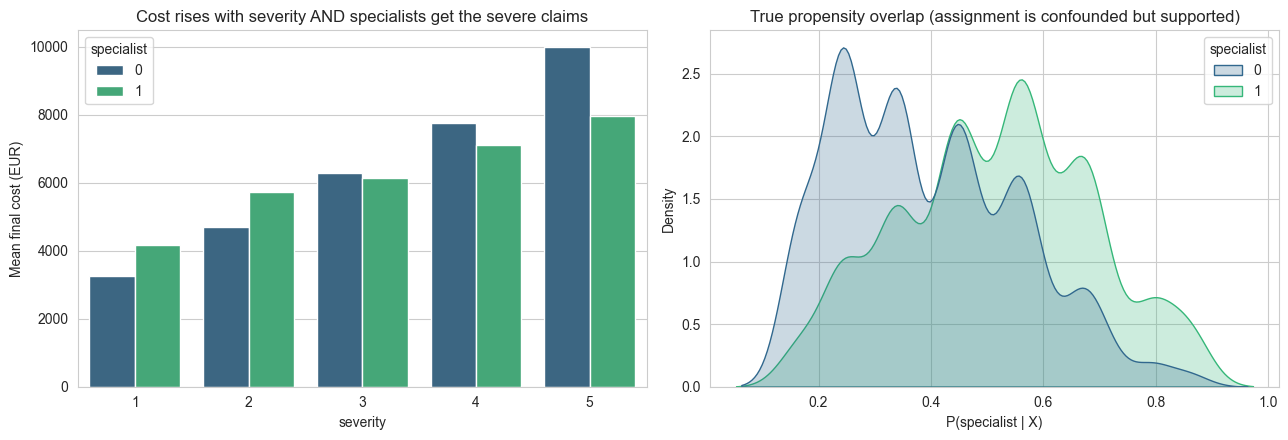

In [ ]:
naive = (claims.loc[claims.specialist == 1, "final_cost"].mean()
         - claims.loc[claims.specialist == 0, "final_cost"].mean())

print(f"Naive difference (specialist - standard): CHF {naive:,.0f}  <-- confounded: saving is hidden")
print(f"True ATE:                                 CHF {tau_true.mean():,.0f}  <-- specialists actually SAVE this much")

# Why? Specialists were assigned the complex (expensive) claims.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=claims, x="severity", y="final_cost", hue="specialist",
            ax=ax[0], palette=[SAV_GREY_LIGHT, SAV_GREEN], errorbar=None)
ax[0].set_title("Cost rises with severity AND specialists get the severe claims")
ax[0].set_ylabel("Mean final cost (CHF)")
ax[0].legend(title="specialist")

sns.kdeplot(data=claims, x="propensity_true", hue="specialist",
            common_norm=False, fill=True, ax=ax[1], palette=[SAV_GREY_LIGHT, SAV_GREEN])
ax[1].set_title("True propensity overlap (assignment is confounded but supported)")
ax[1].set_xlabel("P(specialist | X)")
plt.tight_layout()
plt.show()

## 3. Method from {doc}`../tutorial/regression_methods`: Double Machine Learning

Our first estimator is **Double Machine Learning** ({prf:ref}`alg-dml`), a *regression* method. It removes the confounding by *partialling out* the claim features from both the outcome and the treatment:

1. predict cost from features, $\hat{\mu}(X)=\mathbb{E}[Y\mid X]$, and take the residual $\tilde{Y}=Y-\hat{\mu}(X)$;
2. predict the routing decision from features, $\hat{\pi}(X)=\mathbb{E}[T\mid X]$ (the propensity), and take $\tilde{T}=T-\hat{\pi}(X)$;
3. regress $\tilde{Y}$ on $\tilde{T}$ to read off the **average** effect $\hat{\tau}$.

Cross-fitting (the `cv` argument) supplies the out-of-bag nuisance predictions $\hat{Y}^{(-i)}$ and $\hat{\pi}^{(-i)}$ and makes the estimate Neyman-orthogonal — first-stage ML errors only matter at second order. We pass the features as controls `W` so DML targets a single debiased ATE.


In [ ]:
Xmat = claims[feature_cols].values
Tarr = claims["specialist"].values.astype(int)
Yarr = claims["final_cost"].values.astype(float)

dml = LinearDML(
    model_y=GradientBoostingRegressor(random_state=0),
    model_t=RandomForestClassifier(n_estimators=300, random_state=0),
    discrete_treatment=True,
    cv=5,
    random_state=0,
)
# X=None, W=features  ->  partial out the confounders and estimate one debiased ATE
with np.errstate(all="ignore"):       # silence harmless matmul overflow in econml's inference
    dml.fit(Yarr, Tarr, X=None, W=Xmat)
    ate = dml.ate()
    lb, ub = dml.ate_interval(alpha=0.05)
print("Average treatment effect of specialist handling on final cost")
print(f"  Naive (confounded):  CHF {naive:,.0f}")
print(f"  DML estimate:        CHF {ate:,.0f}   (95% CI {lb:,.0f} .. {ub:,.0f})")
print(f"  True ATE:            CHF {tau_true.mean():,.0f}")

Average treatment effect of specialist handling on final cost
  Naive (confounded):  EUR 785
  DML estimate:        EUR -1,009   (95% CI -1,211 .. -806)
  True ATE:            EUR -893


## 4. Method from {doc}`../tutorial/Tree_Based_Methods`: Causal Forest

DML gives one number. For triage we need the **individual** effect $\hat{\tau}(x)$, so we turn to a **Causal Forest** ({prf:ref}`alg-causalforest`) — the *tree-based* method. It is a locally-weighted, non-parametric R-learner: each honest tree splits the claims to **maximise heterogeneity** $n_L n_R(\hat{\tau}_L-\hat{\tau}_R)^2$ in the effect (not to predict cost), and the forest combines trees into adaptive neighbourhood weights $\alpha^{(j)}(x)$. Two claims are "similar" when they repeatedly share a leaf, so the forest learns a data-driven match in feature space while staying doubly robust through the same residualisation as DML.


Causal-forest average CATE: EUR -987   (true ATE EUR -893)


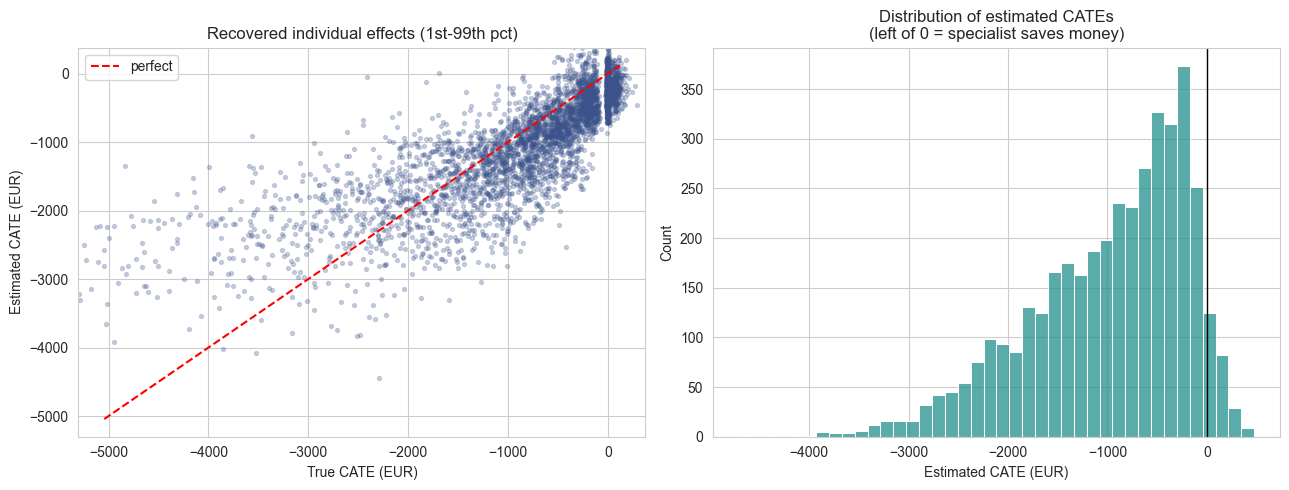

In [ ]:
cf = CausalForestDML(
    model_y=GradientBoostingRegressor(random_state=0),
    model_t=RandomForestClassifier(n_estimators=300, random_state=0),
    discrete_treatment=True,
    n_estimators=1000,
    min_samples_leaf=10,
    cv=5,
    random_state=0,
)
cf.fit(Yarr, Tarr, X=Xmat)

claims["tau_hat"] = cf.effect(Xmat)
print(f"Causal-forest average CATE: CHF {claims.tau_hat.mean():,.0f}   (true ATE CHF {tau_true.mean():,.0f})")

# How well does the forest recover the hidden individual effects?
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Focus the axes on the bulk (1st-99th percentile); a few very large claims have extreme effects
lo, hi = np.percentile(claims.tau_true, [1, 99])
pad = 0.05 * (hi - lo)
ax[0].scatter(claims.tau_true, claims.tau_hat, s=8, alpha=0.25, color=SAV_CHARCOAL)
ax[0].plot([lo, hi], [lo, hi], "--", color=SAV_GREEN_DARK, lw=1.5, label="perfect")
ax[0].set(xlabel="True CATE (CHF)", ylabel="Estimated CATE (CHF)",
          title="Recovered individual effects (1st-99th pct)",
          xlim=(lo - pad, hi + pad), ylim=(lo - pad, hi + pad))
ax[0].legend()

sns.histplot(claims.tau_hat, bins=40, ax=ax[1], color=SAV_GREEN)
ax[1].axvline(0, color="k", lw=1)
ax[1].set(title="Distribution of estimated CATEs\n(left of 0 = specialist saves money)",
          xlabel="Estimated CATE (CHF)")
plt.tight_layout()
plt.show()

### Why is the effect heterogeneous?

The histogram above is not noise — the specialist's value genuinely *depends on the claim*. A specialist helps only when there is **room to act**: reserves to renegotiate, liability to dispute, medical bills to scrutinise, or fraud to detect. That room scales with the **complexity** of the claim, so the effect $\hat{\tau}(x)$ ranges from a large saving to roughly zero (or even a small loss, once the review overhead is counted). Two concrete claims make this tangible:

- **Example A — severe injury, disputed liability (large saving).** A high-`severity` collision with bodily `injury` and a `third_party` involved has a large, *negotiable* reserve. A specialist challenges inflated medical and repair estimates, manages the litigation, and settles for less. Here $-\hat{\tau}(x)$ is several thousand CHF — exactly the claims the causal forest pushes into the left tail of the distribution.
- **Example B — minor windshield bump, no injury (≈ zero or slightly negative).** A low-`severity`, no-`injury` glass or fender claim is already cheap and mechanical: the payout is fixed by a parts catalogue with nothing to negotiate. A specialist adds review time and overhead but cannot lower the cost, so $\hat{\tau}(x)\approx 0$ — and after the CHF 150 handling cost the *net* effect is mildly **negative**.

In the data-generating process this is encoded as `savings_rate = 0.35 * complexity - 0.05`, where `complexity` rises with severity, injury and third-party involvement. The effect therefore **changes sign** across the portfolio — which is precisely why a single ATE is not enough and why triage needs the *individual* $\hat{\tau}(x)$.


## 5. Explaining the effect with Shapley values

A CATE estimate is only actionable if a claims handler can understand *why* a given claim is flagged. **SHAP** (SHapley Additive exPlanations) attributes each claim's predicted effect to its features, so we move from a black-box number to an auditable explanation. `econml` ships a SHAP wrapper for the causal forest; we explain a subsample for speed.

The **beeswarm** plot below summarises the whole portfolio: each dot is a claim, its horizontal position is that feature's contribution to the predicted effect, and the colour is the feature value. We expect `severity` and `injury` to push the effect **downward** (more saving) when they are high — exactly the complexity drivers we built in.


100%|===================| 399/400 [00:16<00:00]        

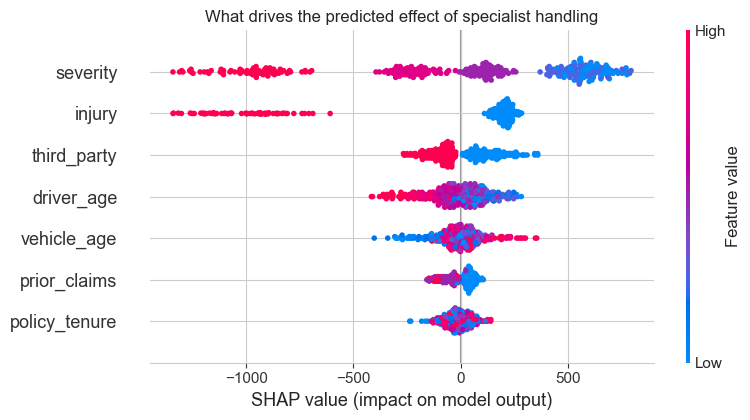

In [31]:
# Explain a subsample of claims (SHAP on a forest is expensive)
sample = claims.iloc[:400].reset_index(drop=True)
X_sample = sample[feature_cols]

shap_dict = cf.shap_values(X_sample)
# econml returns {outcome: {treatment: shap.Explanation}}; grab the single Explanation
out_key = list(shap_dict.keys())[0]
trt_key = list(shap_dict[out_key].keys())[0]
expl = shap_dict[out_key][trt_key]

shap.plots.beeswarm(expl, show=False)
plt.title("What drives the predicted effect of specialist handling")
plt.tight_layout()
plt.show()

### Per-claim explanation: the waterfall plot

Triage happens one claim at a time, so we zoom into a single incoming claim. The **waterfall** plot starts from the portfolio-average effect $\mathbb{E}[\hat{\tau}]$ and adds each feature's contribution until it reaches this claim's predicted effect $\hat{\tau}(x)$. This is the explanation a handler would see next to the routing recommendation. We pick the claim with the **largest predicted saving**.


Selected claim features:
severity          5.0
injury            1.0
third_party       1.0
driver_age       51.0
vehicle_age       4.0
prior_claims      0.0
policy_tenure    16.0

Predicted effect (CATE): EUR -3,738   (negative = saving)
True effect:             EUR -2,709


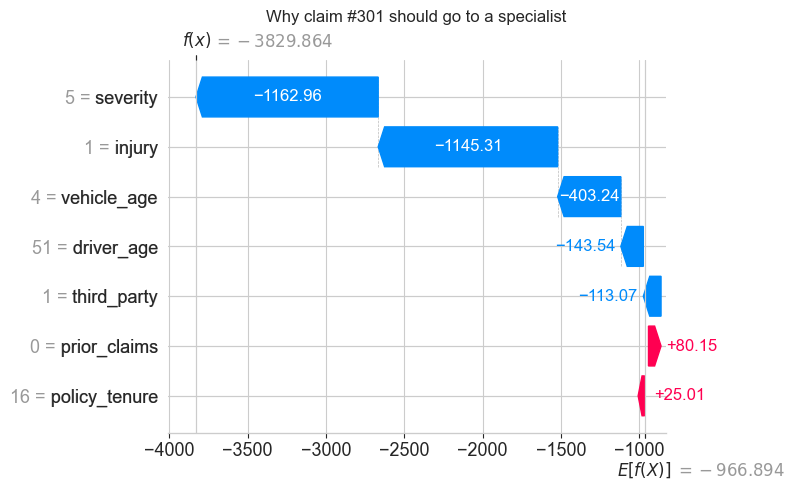

In [ ]:
# Claim with the biggest predicted saving (most negative effect) in the explained sample
idx = int(np.argmin(expl.values.sum(axis=1)))

print("Selected claim features:")
print(sample.loc[idx, feature_cols].to_string())
print(f"\nPredicted effect (CATE): CHF {sample.loc[idx, 'tau_hat']:,.0f}   (negative = saving)")
print(f"True effect:             CHF {sample.loc[idx, 'tau_true']:,.0f}")

shap.plots.waterfall(expl[idx], show=False)
plt.title(f"Why claim #{idx} should go to a specialist")
plt.tight_layout()
plt.show()

## 6. From effects to a triage policy

Specialists are a **scarce resource** — they can review only a fraction of the incoming queue. Triage is therefore a *ranking* problem: given a capacity of, say, **30%** of claims, *which* claims should jump the queue? We compare three ways to spend that capacity:

- **Random** — send a random 30% (a lower bar).
- **Heuristic: highest severity first** — what many insurers do today, routing by a simple risk flag known at triage.
- **Targeted (CATE)** — send the 30% with the most negative predicted effect $\hat{\tau}(x)$.


Each claim still carries a small handling overhead. We grade all three against the *hidden* ground truth, counting realised leakage savings minus overhead spent.

```{admonition} The triage rule is a constrained optimization
:class: tip
Formally we choose a routing decision $a_i \in \{0,1\}$ per claim to

$$\max_{a}\; \sum_{i=1}^{n} a_i\,\bigl(-\hat{\tau}(x_i) - c\bigr)
\qquad \text{s.t.} \qquad \sum_{i=1}^{n} a_i \le K,$$

where $-\hat{\tau}(x_i)$ is the predicted saving, $c$ the per-review overhead, and $K$ the specialist capacity. Because each claim contributes independently and the only coupling is the single capacity budget, the optimum is *not* a hard combinatorial search — it reduces to **rank by predicted net benefit and take the top $K$**. (It would become a genuine knapsack/LP only if claims consumed different amounts of specialist time or there were several resource pools.)

**The deliverable is therefore a policy — a *Regelwerk*:** the scoring function $x \mapsto \hat{\tau}(x)$ plus a capacity-driven cutoff, i.e. *"route a claim iff its predicted saving ranks in the top $K$."* The SHAP layer from Section 5 is what makes every individual decision under that rule auditable.
```


Specialist capacity: 30% of the queue (1,200 claims)

                     share_routed  claims_to_specialist  net_saving_chf
Random 30%                    30%                  1200          849541
Highest severity 30%          30%                  1200         1923305
Targeted CATE 30%             30%                  1200         2247337


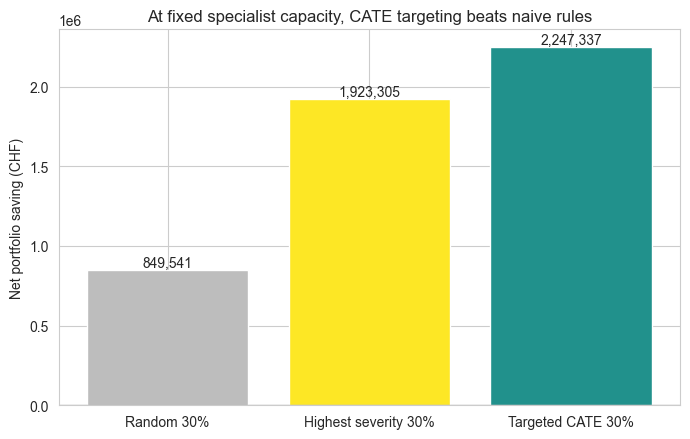

In [ ]:
overhead = 150.0       # CHF cost of a specialist review
capacity = 0.30        # specialists can handle at most 30% of the queue
k = int(capacity * len(claims))

def top_k_mask(scores, k, largest=True):
    """Boolean mask selecting the k claims with the highest (or lowest) score."""
    order = np.argsort(scores)
    chosen = order[-k:] if largest else order[:k]
    mask = np.zeros(len(scores), dtype=bool)
    mask[chosen] = True
    return mask

def net_saving(mask):
    # realised saving = -sum(true effect) on routed claims, minus overhead paid
    return float(-claims.loc[mask, "tau_true"].sum() - overhead * mask.sum())

rng_pol = np.random.default_rng(0)
random_mask = np.zeros(len(claims), dtype=bool)
random_mask[rng_pol.choice(len(claims), k, replace=False)] = True

claims["route_specialist"] = top_k_mask(claims.tau_hat.values, k, largest=False)  # most negative CATE

policies = {
    "Random 30%":            random_mask,
    "Highest severity 30%":  top_k_mask(claims.severity.values, k, largest=True),
    "Targeted CATE 30%":     claims.route_specialist.values,
}
results = pd.DataFrame({
    "claims_to_specialist": {key: int(v.sum()) for key, v in policies.items()},
    "net_saving_chf":       {key: round(net_saving(v)) for key, v in policies.items()},
})
results["share_routed"] = (results.claims_to_specialist / len(claims)).map("{:.0%}".format)
print(f"Specialist capacity: {capacity:.0%} of the queue ({k:,} claims)\n")
print(results[["share_routed", "claims_to_specialist", "net_saving_chf"]])

plt.figure(figsize=(7, 4.5))
colors = [SAV_GREY_LIGHT, SAV_GREEN_LIGHT, SAV_GREEN]
plt.bar(results.index, results.net_saving_chf, color=colors)
plt.ylabel("Net portfolio saving (CHF)")
plt.title("At fixed specialist capacity, CATE targeting beats naive rules")
for i, v in enumerate(results.net_saving_chf):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()


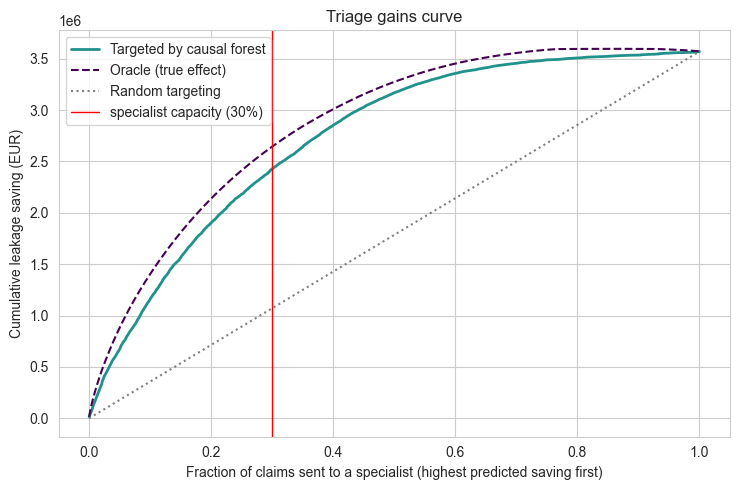

In [ ]:
# Cumulative-gains curve: rank claims by predicted saving, add real savings in that order
order = claims.sort_values("tau_hat").index           # biggest predicted saving first
cum_true = -claims.loc[order, "tau_true"].cumsum().values
frac = np.arange(1, len(claims) + 1) / len(claims)

# Best-possible (oracle) ordering by the true effect, and random targeting
oracle = -claims.sort_values("tau_true")["tau_true"].cumsum().values
random_line = np.linspace(0, -claims.tau_true.sum(), len(claims))

plt.figure(figsize=(7.5, 5))
plt.plot(frac, cum_true, label="Targeted by causal forest", color=SAV_GREEN, lw=2)
plt.plot(frac, oracle, "--", label="Oracle (true effect)", color=SAV_CHARCOAL, lw=1.5)
plt.plot(frac, random_line, ":", label="Random targeting", color=SAV_GREY)
plt.axvline(capacity, color=SAV_GREEN_DARK, lw=1,
            label=f"specialist capacity ({capacity:.0%})")
plt.xlabel("Fraction of claims sent to a specialist (highest predicted saving first)")
plt.ylabel("Cumulative leakage saving (CHF)")
plt.title("Triage gains curve")
plt.legend()
plt.tight_layout()
plt.show()

## 7. How robust is the saving to unmeasured confounding?

Every number above rests on **unconfoundedness**: we assumed adjusters routed claims using only the features in $X$. In reality they may have acted on something we never recorded — a photo of the damage, a phone call, a gut feeling. Such a hidden confounder $U$ would bias our estimate. **Sensitivity analysis** asks the key question from {doc}`../tutorial/diagnostics`:

> *How strongly would an unobserved confounder have to act on both the routing decision and the cost to explain away the estimated saving?*

We use the omitted-variable framework for Double Machine Learning ([Chernozhukov et al., 2022](https://doi.org/10.3982/ECTA19345)), the DML counterpart of the partial-$R^2$ / **robustness value** approach of [Cinelli & Hazlett (2020)](https://doi.org/10.1111/rssb.12348). A confounder is summarised by two numbers: its partial $R^2$ with the treatment ($c_t$) and with the outcome ($c_y$) — i.e. how much residual variation in *who gets a specialist* and in *final cost* it would explain.


In [ ]:
# Robustness value: the partial R^2 a confounder needs with BOTH T and Y to push
# the estimate (or its 95% CI) to zero. Larger = more robust.
with np.errstate(all="ignore"):
    rv_point = dml.robustness_value(null_hypothesis=0, alpha=1.0)    # to move the point estimate
    rv_ci    = dml.robustness_value(null_hypothesis=0, alpha=0.05)   # to move the 95% CI bound

print(f"DML estimate of the saving:      CHF {ate:,.0f}  (95% CI {lb:,.0f} .. {ub:,.0f})")
print(f"Robustness value (point est.):   RV   = {rv_point:.3f}")
print(f"Robustness value (95% CI):       RV_a = {rv_ci:.3f}")
print()
print(f"-> A hidden confounder would have to explain at least {rv_point:.0%} of the residual")
print(f"   variation in BOTH routing and cost to wipe out the estimated saving entirely,")
print(f"   and {rv_ci:.0%} to render it statistically insignificant.")

# econml's own one-line summary for reference (modest benchmark confounder, c_t = c_y = 0.05)
with np.errstate(all="ignore"):
    print("\n--- econml sensitivity_summary (benchmark confounder c_t = c_y = 0.05) ---")
    print(dml.sensitivity_summary(c_y=0.05, c_t=0.05))

DML estimate of the saving:      EUR -1,009  (95% CI -1,211 .. -806)
Robustness value (point est.):   RV   = 0.155
Robustness value (95% CI):       RV_a = 0.127

-> A hidden confounder would have to explain at least 16% of the residual
   variation in BOTH routing and cost to wipe out the estimated saving entirely,
   and 13% to render it statistically insignificant.

--- econml sensitivity_summary (benchmark confounder c_t = c_y = 0.05) ---
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
 CI Lower Theta Lower  Theta   Theta Upper CI Upper
---------------------------------------------------
-1523.011   -1315.246 -1008.53    -701.814 -503.611
   Robustness Values for null_hypothesis=0    
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.155                 0.127
----------------------------------------------


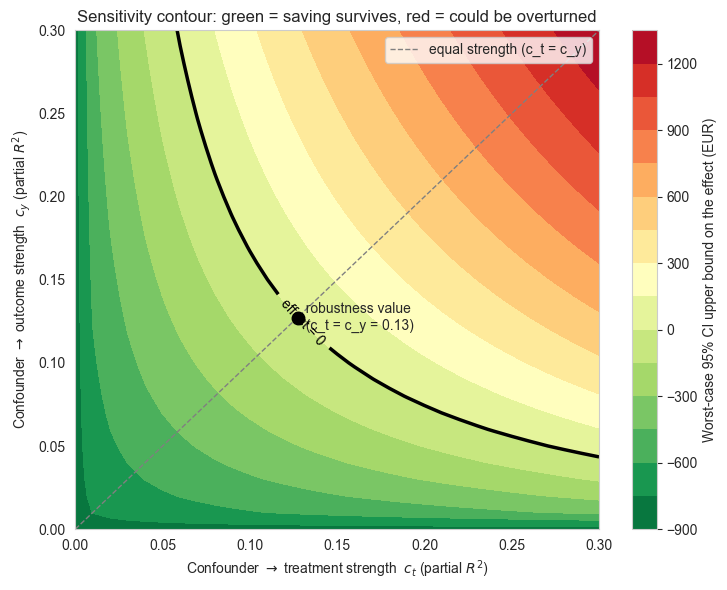

In [ ]:
# Partial-R^2 contour: how the worst-case bound on the saving moves as a confounder
# of strength (c_t, c_y) is introduced. The effect is negative (a saving), so the
# bound nearest zero (the 95% CI upper bound) is the one that could overturn it.
grid = np.linspace(0.0, 0.30, 31)
CT, CY = np.meshgrid(grid, grid)
bound = np.zeros_like(CT)
with np.errstate(all="ignore"):
    for a in range(CT.shape[0]):
        for b in range(CT.shape[1]):
            _, ub_ab = dml.sensitivity_interval(c_t=CT[a, b], c_y=CY[a, b],
                                                 interval_type="ci")
            bound[a, b] = ub_ab

fig, ax = plt.subplots(figsize=(7.5, 6))
cf_plot = ax.contourf(CT, CY, bound, levels=20, cmap="sav_div_r")
cbar = fig.colorbar(cf_plot, ax=ax)
cbar.set_label("Worst-case 95% CI upper bound on the effect (CHF)")

# The critical contour: where the bound first touches zero (saving no longer certain)
zero = ax.contour(CT, CY, bound, levels=[0], colors="black", linewidths=2.5)
ax.clabel(zero, fmt="effect = 0", inline=True, fontsize=10)

# Robustness value: the point on the diagonal c_t = c_y where the CI bound hits zero
ax.plot(rv_ci, rv_ci, "o", color="black", ms=9, zorder=5)
ax.annotate(f"  robustness value\n  (c_t = c_y = {rv_ci:.2f})",
            (rv_ci, rv_ci), fontsize=10, va="center")
ax.plot([0, 0.30], [0, 0.30], "--", color="grey", lw=1, label="equal strength (c_t = c_y)")

ax.set_xlabel(r"Confounder $\to$ treatment strength  $c_t$ (partial $R^2$)")
ax.set_ylabel(r"Confounder $\to$ outcome strength  $c_y$ (partial $R^2$)")
ax.set_title("Sensitivity contour: green = saving survives, grey = could be overturned")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Reading the contour.** The green region is where the estimated saving survives; the grey region is where a confounder of that strength could overturn it. The black line is the tipping point, and the dot marks the **robustness value** — a confounder would need to explain about **13%** of the residual variation in *both* routing and cost (equal strength) before the 95% CI for the saving touches zero.

Is that a lot? As a benchmark, none of our *observed* features (severity, injury, third party, ...) individually explains anywhere near 13% of the residual variation in both directions once the others are controlled for. So an unobserved confounder would have to be **stronger than any single recorded claim feature** to erase the saving — the triage conclusion is reasonably robust, though not bulletproof. In practice one would pair this with the {doc}`sensitivity_analysis` E-value and Rosenbaum diagnostics before committing the policy.


### Robustness of the *heterogeneous* effect

The robustness value above is a single number for the whole portfolio — but our triage policy never acts on the portfolio average, it acts on **individual** effects $\hat{\tau}(x)$. The honest sensitivity question is therefore *heterogeneous* too:

> *Is the saving on the claims we actually route as robust as the saving on the ones we leave alone?*

Because confounding bias adds (roughly) the **same** worst-case shift to every effect, a claim with a *large* predicted saving can absorb far more bias before its sign flips than a claim whose effect is already near zero. We make this concrete by re-running the DML omitted-variable analysis **within severity strata** and reading off a robustness value for each. This turns one portfolio RV into a *profile* of RVs across the heterogeneity.


        subgroup    n  cate_chf  ci_low  ci_high  robustness_value
 Minor (sev 1-2) 1593      -212    -455       31             0.000
Moderate (sev 3)  829     -1056   -1476     -637             0.101
Severe (sev 4-5) 1578     -1698   -2088    -1307             0.169


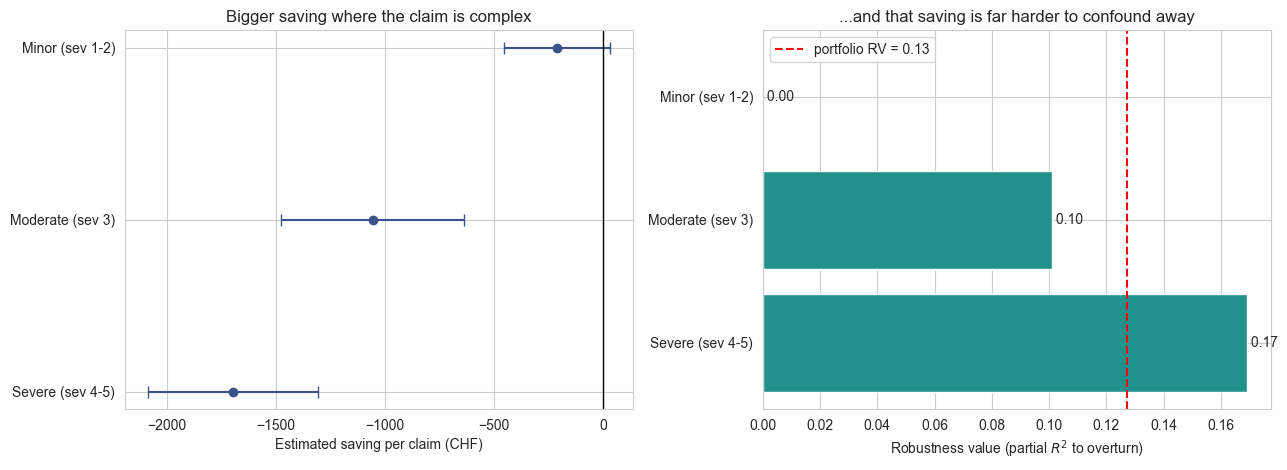

In [ ]:
# Re-run the DML omitted-variable analysis WITHIN severity strata to get a
# robustness value for each part of the heterogeneity.
strata = {
    "Minor (sev 1-2)":  (claims.severity <= 2).values,
    "Moderate (sev 3)": (claims.severity == 3).values,
    "Severe (sev 4-5)": (claims.severity >= 4).values,
}

rows = []
for name, m in strata.items():
    d = LinearDML(
        model_y=GradientBoostingRegressor(random_state=0),
        model_t=RandomForestClassifier(n_estimators=300, random_state=0),
        discrete_treatment=True, cv=5, random_state=0,
    )
    with np.errstate(all="ignore"):
        d.fit(Yarr[m], Tarr[m], X=None, W=Xmat[m])
        a = d.ate()
        l, u = d.ate_interval(alpha=0.05)
        rv = d.robustness_value(null_hypothesis=0, alpha=0.05)   # to move the 95% CI bound
    rows.append({"subgroup": name, "n": int(m.sum()), "cate_chf": round(a),
                 "ci_low": round(l), "ci_high": round(u), "robustness_value": round(rv, 3)})

sub = pd.DataFrame(rows)
print(sub.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
y = np.arange(len(sub))

# Left: effect with 95% CI per stratum (a forest plot)
ax[0].errorbar(sub.cate_chf, y,
               xerr=[sub.cate_chf - sub.ci_low, sub.ci_high - sub.cate_chf],
               fmt="o", color=SAV_CHARCOAL, capsize=4)
ax[0].axvline(0, color="k", lw=1)
ax[0].set_yticks(y); ax[0].set_yticklabels(sub.subgroup)
ax[0].set_xlabel("Estimated saving per claim (CHF)")
ax[0].set_title("Bigger saving where the claim is complex")
ax[0].invert_yaxis()

# Right: robustness value per stratum, with the portfolio RV as reference
ax[1].barh(y, sub.robustness_value, color=SAV_GREEN)
ax[1].axvline(rv_ci, color=SAV_GREEN_DARK, lw=1.5, ls="--",
              label=f"portfolio RV = {rv_ci:.2f}")
ax[1].set_yticks(y); ax[1].set_yticklabels(sub.subgroup)
ax[1].set_xlabel("Robustness value (partial $R^2$ to overturn)")
ax[1].set_title("...and that saving is far harder to confound away")
ax[1].invert_yaxis(); ax[1].legend()
for yi, v in zip(y, sub.robustness_value):
    ax[1].text(v, yi, f" {v:.2f}", va="center")
plt.tight_layout()
plt.show()


**Reading the profile.** The robustness value tracks the heterogeneity almost perfectly:

- **Severe claims (sev 4-5)** carry the largest saving (≈ CHF 1,700/claim) and the **highest robustness value (≈ 0.17)** — *above* the portfolio figure of 0.13. A confounder would have to be exceptionally strong to overturn the case for sending these claims to a specialist.
- **Moderate claims (sev 3)** sit in between (RV ≈ 0.10).
- **Minor claims (sev 1-2)** have a small effect whose confidence interval already straddles zero, so their **robustness value is essentially 0** — the "saving" here is fragile and could vanish under even mild confounding.

This is exactly the reassurance the triage policy needs: the claims our rule actually routes — the high-severity, high-saving ones — are precisely the claims whose conclusion is **most robust** to unmeasured confounding. The fragile, near-zero estimates belong to minor claims that the policy leaves with standard handling anyway, so their sensitivity does not endanger the decisions we make.


## Takeaways for the actuary

```{admonition} A practical workflow for claims triage
:class: tip

1. **Naive comparisons mislead.** Because adjusters routed the hard claims to specialists, a raw cost comparison made specialists look *harmful*; {prf:ref}`alg-dml` corrected the sign and recovered the true average saving.
2. **Effects are heterogeneous.** The {prf:ref}`alg-causalforest` showed the specialist's benefit changes sign across the portfolio — saving money on complex, high-severity, injury-related claims and merely adding overhead on trivial ones.
3. **Explainability makes it operational.** SHAP beeswarm and waterfall plots turn each CATE into an auditable, per-claim rationale a handler can trust and act on.
4. **Targeting pays under scarcity.** With specialists limited to a fraction of the queue, ranking claims by predicted saving captures far more leakage reduction than a random or highest-severity-first rule, and the gains curve quantifies the benefit at any capacity level.
5. **The output is a *triage policy*.** The exercise delivers a triage policy — score each incoming claim by $\hat{\tau}(x)$ and route the top ones until specialist capacity is exhausted — i.e. the solution of a capacity-constrained optimization, made auditable claim-by-claim through SHAP.
6. **Robust, but not unconditionally.** The partial-$R^2$ sensitivity analysis shows the saving only collapses if an *unobserved* confounder is stronger than any feature we already record (portfolio robustness value ≈ 0.13). Tailored to the heterogeneity, the *severe* claims we actually route are the **most** robust (RV ≈ 0.17), while the fragile near-zero estimates belong to minor claims the policy leaves alone — so unmeasured confounding threatens the decisions we make least of all.
```

**The bottom line.** The conclusions rest on **unconfoundedness** and **overlap**. Section 7 quantified the first: the saving survives unless an unobserved confounder is unusually strong — and, claim for claim, the severe cases we route are the most robust. If you suspect such a confounder, complement the partial-$R^2$ contour with the E-value and Rosenbaum diagnostics in {doc}`sensitivity_analysis` before deploying a triage policy.